# Trajectory study — stylistic evolution, and who evolved alike

Everything upstream is done: clean per-season style vectors are on disk. This notebook is the
analytics problem on top — **you model, it prints**.

| section | state |
|---|---|
| 0 · setup, 1 · data cleaning | done — run through |
| 2 · modeling (DTW + alternatives) | **skeleton — you implement** |
| 3 · trajectory search | plumbing done, uses your `dtw` |
| 4 · visualization | done — PCA career map + drift ranking |
| 5 · output analysis | questions to answer |

Data: `data/models/baseline_vectors.parquet` — 66 z-scored, team-residualized style features per
(player, team, season). Reading: Müller *IR for Music and Motion* ch.4 (DTW); Shokoohi-Yekta 2017
(multivariate DTW); Toohey & Duckham 2015 (the wider family).

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / 'config.yaml').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src' / 'models'))
from trajectories import load_vectors, feature_cols, build_sequences, pca_project

# fixed categorical order, never cycled; max ~5 careers per plot, then facet
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
GROUND = '#d9d9d4'   # the population, always recessive
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

vec = load_vectors(ROOT)
FEATURES = feature_cols(vec)
print(f'{len(vec):,} entities x {len(FEATURES)} features')

17,826 entities x 66 features


## 1 · Data cleaning — entity table → career sequences

One career = one player's **club** seasons with enough minutes, ordered in time. Seasons stay
separate points (2026-08-11 amendment: no pooling). Gaps are *flagged*, not hidden — a
2020/21→2023/24 jump is missing data, not a style explosion (see `reports/style_drift.md`).

In [2]:
MIN_MINUTES = 450        # D15: support thresholds are explicit, always stated
seqs = build_sequences(vec, min_minutes=MIN_MINUTES, context='club', min_seasons=2)

lens = pd.Series({s.player: len(s.seasons) for s in seqs.values()})
print(f'{len(seqs)} players with >= 2 club seasons at {MIN_MINUTES}+ min')
print('seasons per career:', dict(lens.value_counts().sort_index()))
gappy = [s.player for s in seqs.values() if s.has_gaps]
print(f'{len(gappy)} careers contain season gaps — compare those with care')

388 players with >= 2 club seasons at 450+ min
seasons per career: {2: 204, 3: 111, 4: 51, 5: 3, 6: 6, 7: 3, 8: 2, 9: 2, 10: 1, 11: 1, 13: 1, 14: 2, 18: 1}
220 careers contain season gaps — compare those with care


## 2 · Modeling — distances between careers

Worked example first (adjacent drift), then the part that's yours: **dependent multivariate
DTW** over season matrices, plus at least one order-blind alternative so you can say whether
DTW earns its complexity on careers this short (2–17 seasons).

In [3]:
def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return a @ b / (na * nb) if na and nb else np.nan

# worked example — mean adjacent-season drift: how fast does a style move?
drift = pd.DataFrame([
    {'player': s.player, 'pos': s.pos_group, 'n_seasons': len(s.X),
     'mean_adjacent_cosine': np.mean([cos(s.X[i], s.X[i+1]) for i in range(len(s.X)-1)])}
    for s in seqs.values()])
drift.sort_values('mean_adjacent_cosine').head(10)

,player,pos,n_seasons,mean_adjacent_cosine
204,Nora Heroum,FW,2,-0.263551
82,Rachel Daly,FW,3,-0.087623
294,Jessica Carter,DF,2,-0.066989
304,Rachel Rowe,DF,2,-0.003221
339,Gun Nathalie Björn,DF,2,0.032262
46,Ibrahim Afellay,FW,2,0.050976
53,Rebecca Quinn,DF,2,0.069680
86,Kristen Edmonds,DF,2,0.088294
386,Emily Ann Fox,DF,2,0.113791
110,José Martín Cáceres Silva,DF,2,0.115543


In [4]:
def dtw(A, B, ground=lambda a, b: 1 - cos(a, b)):
    """Dependent multivariate DTW between two (n_seasons, d) matrices,
    normalised by the length of the optimal warping path (Mueller ch.4;
    Sakoe & Chiba 1978). Symmetric, non-negative, zero on identical careers."""
    n, m = len(A), len(B)
    G = np.array([[ground(a, b) for b in B] for a in A])
    D = np.zeros((n, m))              # accumulated cost
    L = np.zeros((n, m), dtype=int)   # path length, for the normalisation
    D[0, 0], L[0, 0] = G[0, 0], 1
    for i in range(1, n):
        D[i, 0], L[i, 0] = D[i-1, 0] + G[i, 0], i + 1
    for j in range(1, m):
        D[0, j], L[0, j] = D[0, j-1] + G[0, j], j + 1
    for i in range(1, n):
        for j in range(1, m):
            steps = ((i-1, j-1), (i-1, j), (i, j-1))   # both advance / A dwells / B dwells
            best = min(steps, key=lambda s: D[s])
            D[i, j], L[i, j] = G[i, j] + D[best], L[best] + 1
    return D[-1, -1] / L[-1, -1]


def mean_pairwise(A, B, ground=lambda a, b: 1 - cos(a, b)):
    """Order-blind alternative: mean ground distance over all season pairs."""
    return float(np.mean([[ground(a, b) for b in B] for a in A]))


def drift_direction_similarity(A, B):
    """Compare *directions of change*: cosine between (last - first) vectors.
    Two players can occupy different regions yet evolve the same way."""
    return cos(A[-1] - A[0], B[-1] - B[0])

In [5]:
# sanity checks — all must pass before section 3 is trustworthy:
s0, s1 = list(seqs.values())[0], list(seqs.values())[1]
assert np.isclose(dtw(s0.X, s0.X), 0, atol=1e-9)         # self-distance is zero
assert np.isclose(dtw(s0.X, s1.X), dtw(s1.X, s0.X))      # symmetric
assert dtw(s0.X, s1.X) >= 0                               # non-negative
assert np.isclose(mean_pairwise(s0.X, s1.X), mean_pairwise(s1.X, s0.X))
print('all sanity checks pass')

all sanity checks pass


## 3 · Trajectory search — who evolved like X?

Plumbing is done; it calls whatever distance you hand it. Restrict to 3+ season careers —
two points is a line segment, not a trajectory.

In [6]:
def trajectory_neighbours(name, dist=None, min_seasons=3, k=10):
    dist = dist or dtw
    pool = [s for s in seqs.values() if len(s.X) >= min_seasons]
    target = next(s for s in pool if name.lower() in s.player.lower())
    rows = [{'player': s.player, 'pos': s.pos_group, 'seasons': len(s.X),
             'gaps': s.has_gaps, 'distance': dist(target.X, s.X)}
            for s in pool if s.player_id != target.player_id]
    print(f'target: {target.player} ({len(target.X)} seasons)')
    return pd.DataFrame(rows).nsmallest(k, 'distance')

trajectory_neighbours('Messi Cuccittini')

target: Lionel Andrés Messi Cuccittini (18 seasons)


,player,pos,seasons,gaps,distance
178,Kit Graham,FW,3,True,0.311765
139,Samuel Eto''o Fils,FW,5,False,0.321615
173,Ella Toone,MF,3,True,0.355371
43,Antoine Griezmann,FW,3,True,0.385505
113,Brooke Chaplen,FW,3,False,0.387047
42,Ousmane Dembélé,FW,4,True,0.397235
107,Vivianne Miedema,FW,3,False,0.435406
102,Rinsola Babajide,FW,3,True,0.437810
180,Martha Thomas,FW,3,True,0.442115
12,Francesca Kirby,FW,3,True,0.443347


In [7]:
# does order matter at these career lengths? rank-compare the two measures
full_dtw = trajectory_neighbours('Messi Cuccittini', k=10**6)
full_mp = trajectory_neighbours('Messi Cuccittini', dist=mean_pairwise, k=10**6)
cmp = full_dtw.merge(full_mp, on='player', suffixes=('_dtw', '_mp'))
rho = cmp.distance_dtw.corr(cmp.distance_mp, method='spearman')
print(f'spearman rank agreement, dtw vs mean_pairwise: {rho:.3f}')

# and the third lens: same *direction* of evolution, wherever they started
trajectory_neighbours('Messi Cuccittini',
                      dist=lambda A, B: 1 - drift_direction_similarity(A, B))

target: Lionel Andrés Messi Cuccittini (18 seasons)
target: Lionel Andrés Messi Cuccittini (18 seasons)
spearman rank agreement, dtw vs mean_pairwise: 0.985
target: Lionel Andrés Messi Cuccittini (18 seasons)


,player,pos,seasons,gaps,distance
6,Neymar da Silva Santos Junior,FW,6,True,0.377946
40,Luis Alberto Suárez Díaz,FW,6,False,0.544135
3,Francesc Fàbregas i Soler,MF,4,True,0.554598
14,Georgia Stanway,MF,4,True,0.561137
160,Abigail Harrison,FW,3,True,0.567833
170,Lauren James,FW,3,True,0.573173
2,Alexis Alejandro Sánchez Sánchez,FW,4,True,0.580712
164,Ronaldo de Assis Moreira,FW,4,False,0.597810
73,Noelle Maritz,DF,3,True,0.614146
39,Andrés Iniesta Luján,FW,14,False,0.620687


## 4 · Visualization — the career map

PCA of the full style space; population in gray, careers as labeled polylines. Single-measure
charts stay single-hue; identity charts use the fixed palette order.

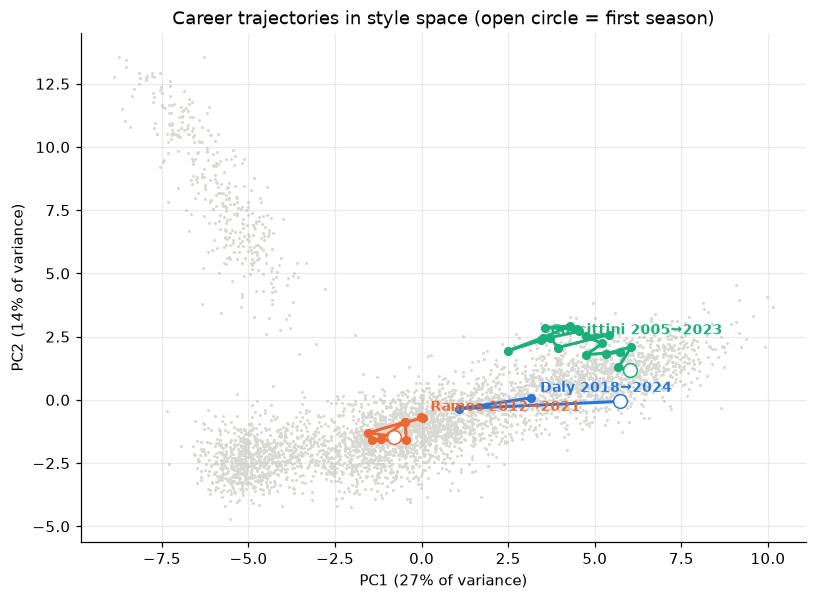

In [8]:
P2, evr = pca_project(vec, FEATURES, min_minutes=MIN_MINUTES)

def plot_careers(names):
    shown = [s for s in seqs.values()
             if any(n.lower() in s.player.lower() for n in names)][:len(PALETTE)]
    fig, ax = plt.subplots(figsize=(8.5, 6))
    solid = vec.minutes >= MIN_MINUTES
    ax.scatter(P2[solid, 0], P2[solid, 1], s=4, c=GROUND, linewidths=0, zorder=1)
    for color, s in zip(PALETTE, shown):
        pts = P2[s.idx]
        ax.plot(pts[:, 0], pts[:, 1], '-o', color=color, lw=2, ms=5, zorder=3)
        ax.plot(pts[0, 0], pts[0, 1], 'o', color=color, ms=9, mfc='white', zorder=3)
        ax.annotate(f"{s.player.split()[-1]} {s.seasons[0][:4]}\u2192{s.seasons[-1][-4:]}",
                    pts[-1], xytext=(6, 4), textcoords='offset points',
                    fontsize=9, fontweight='bold', color=color)
    ax.set_xlabel(f'PC1 ({evr[0]:.0%} of variance)')
    ax.set_ylabel(f'PC2 ({evr[1]:.0%} of variance)')
    ax.set_title('Career trajectories in style space (open circle = first season)')

plot_careers(['Messi Cuccittini', 'Jordi Alba', 'Rachel Daly'])

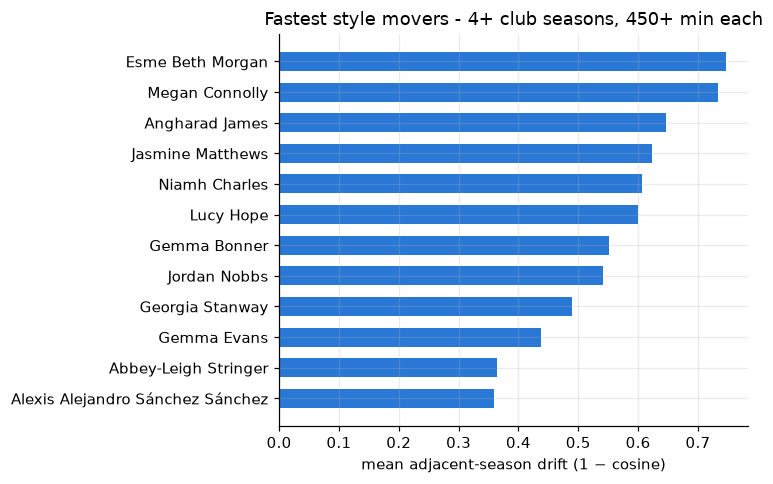

In [9]:
# fastest movers, careers with real support (single measure -> single hue)
top = drift[drift.n_seasons >= 4].nsmallest(12, 'mean_adjacent_cosine')
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top.player, 1 - top.mean_adjacent_cosine, color=PALETTE[0], height=0.62)
ax.invert_yaxis()
ax.set_xlabel('mean adjacent-season drift (1 \u2212 cosine)')
ax.set_title(f'Fastest style movers - 4+ club seasons, {MIN_MINUTES}+ min each')
plt.tight_layout()

## 5 · Output analysis — what to actually conclude

- Do Messi's trajectory neighbours pass the eye test? Who evolved *winger → deep playmaker*?
- Does `mean_pairwise` agree with `dtw`? If ranks barely change, say so in the writeup —
  "DTW wasn't needed at these career lengths" is a legitimate finding.
- Check every surprising neighbour for **gaps** (`gaps` column) and **corpus artifacts**
  (Barcelona players dominate long careers; women's leagues have a 20/21→23/24 hole).
- Keep 2–3 case studies + one chart for the writeup's findings section; wire numbers into
  `reports/02_model_comparison.md` once the eval harness exists.

Scratch space below.